In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [2]:
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


# 12 — Multiple ML Models
### Early Sepsis Detection — Phase 14

Trains Decision Tree, Random Forest, XGBoost, LightGBM, and CatBoost using
the SAME train/val/test arrays and the SAME `evaluate.py` metric suite as
the Phase 13 baseline — for a fair, apples-to-apples comparison.

Each model uses class-weighting (Phase 12) appropriate to its library
(`class_weight='balanced'` for scikit-learn models, `scale_pos_weight`
for XGBoost/LightGBM, `auto_class_weights` for CatBoost) — no model here
has been hyperparameter-tuned yet (that is Phase 15).


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from src import config
from src import evaluate as ev

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_train, y_train = npz["X_train"], npz["y_train"]
X_val, y_val = npz["X_val"], npz["y_val"]
X_test, y_test = npz["X_test"], npz["y_test"]

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_pos_weight:.4f}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


scale_pos_weight = 14.9861
Train: (27560, 464) | Val: (5905, 464) | Test: (5906, 464)


## 1. Decision Tree

A single tree is included as a simple, highly interpretable non-linear
baseline — expected to be weaker than the ensembles below, but useful for
sanity-checking that tree-based splits pick up sensible clinical variables.


In [4]:
dt_model = DecisionTreeClassifier(
    class_weight="balanced", max_depth=8, random_state=config.RANDOM_SEED
)
dt_model.fit(X_train, y_train)

dt_val_prob = dt_model.predict_proba(X_val)[:, 1]
dt_val_metrics = ev.compute_metrics(y_val, dt_val_prob)
ev.print_metrics(dt_val_metrics, "Decision Tree (val)")
ev.save_model_results("Decision_Tree_val", dt_val_metrics)


--- Decision Tree (val) (threshold=0.5) ---
  ROC-AUC:            0.6733
  PR-AUC:             0.1489
  Precision:          0.1181
  Recall (Sensitivity): 0.5772
  Specificity:        0.7126
  F1:                 0.1960
  Brier score:        0.1948
  Confusion matrix:   TN=3945 FP=1591 FN=156 TP=213


2026-09-14 21:38:08,137 | INFO | src.evaluate | Saved/updated results for 'Decision_Tree_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'Decision_Tree_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


## 2. Random Forest

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=12, class_weight="balanced",
    random_state=config.RANDOM_SEED, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_val_prob = rf_model.predict_proba(X_val)[:, 1]
rf_val_metrics = ev.compute_metrics(y_val, rf_val_prob)
ev.print_metrics(rf_val_metrics, "Random Forest (val)")
ev.save_model_results("Random_Forest_val", rf_val_metrics)


2026-09-14 21:38:41,293 | INFO | src.evaluate | Saved/updated results for 'Random_Forest_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'Random_Forest_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


--- Random Forest (val) (threshold=0.5) ---
  ROC-AUC:            0.7035
  PR-AUC:             0.1799
  Precision:          0.2188
  Recall (Sensitivity): 0.1518
  Specificity:        0.9639
  F1:                 0.1792
  Brier score:        0.1044
  Confusion matrix:   TN=5336 FP=200 FN=313 TP=56


## 3. XGBoost

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    random_state=config.RANDOM_SEED, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_val_metrics = ev.compute_metrics(y_val, xgb_val_prob)
ev.print_metrics(xgb_val_metrics, "XGBoost (val)")
ev.save_model_results("XGBoost_val", xgb_val_metrics)


2026-09-14 21:39:02,516 | INFO | src.evaluate | Saved/updated results for 'XGBoost_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'XGBoost_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


--- XGBoost (val) (threshold=0.5) ---
  ROC-AUC:            0.7010
  PR-AUC:             0.1941
  Precision:          0.2179
  Recall (Sensitivity): 0.1978
  Specificity:        0.9527
  F1:                 0.2074
  Brier score:        0.0779
  Confusion matrix:   TN=5274 FP=262 FN=296 TP=73


## 4. LightGBM

In [7]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=config.RANDOM_SEED, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train)

lgb_val_prob = lgb_model.predict_proba(X_val)[:, 1]
lgb_val_metrics = ev.compute_metrics(y_val, lgb_val_prob)
ev.print_metrics(lgb_val_metrics, "LightGBM (val)")
ev.save_model_results("LightGBM_val", lgb_val_metrics)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-09-14 21:39:12,861 | INFO | src.evaluate | Saved/updated results for 'LightGBM_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'LightGBM_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


--- LightGBM (val) (threshold=0.5) ---
  ROC-AUC:            0.7108
  PR-AUC:             0.2074
  Precision:          0.2187
  Recall (Sensitivity): 0.2981
  Specificity:        0.9290
  F1:                 0.2523
  Brier score:        0.0878
  Confusion matrix:   TN=5143 FP=393 FN=259 TP=110


## 5. CatBoost

In [8]:
cb_model = cb.CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.1,
    auto_class_weights="Balanced",
    random_state=config.RANDOM_SEED, verbose=False
)
cb_model.fit(X_train, y_train)

cb_val_prob = cb_model.predict_proba(X_val)[:, 1]
cb_val_metrics = ev.compute_metrics(y_val, cb_val_prob)
ev.print_metrics(cb_val_metrics, "CatBoost (val)")
ev.save_model_results("CatBoost_val", cb_val_metrics)


2026-09-14 21:39:39,706 | INFO | src.evaluate | Saved/updated results for 'CatBoost_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'CatBoost_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


--- CatBoost (val) (threshold=0.5) ---
  ROC-AUC:            0.7228
  PR-AUC:             0.1900
  Precision:          0.1681
  Recall (Sensitivity): 0.3659
  Specificity:        0.8793
  F1:                 0.2304
  Brier score:        0.1180
  Confusion matrix:   TN=4868 FP=668 FN=234 TP=135


## 6. Side-by-side comparison (validation set)

**No claim about which model is "best" is made until this table is
actually produced from real results** — per the project's no-fabrication
requirement.


In [9]:
results = pd.read_csv(config.TABLES_DIR / "model_comparison.csv")
val_results = results[results["model"].str.endswith("_val")].copy()
val_results = val_results.sort_values("pr_auc", ascending=False)
display(val_results[["model", "roc_auc", "pr_auc", "precision", "recall_sensitivity",
                      "specificity", "f1", "brier_score"]])


,model,roc_auc,pr_auc,precision,recall_sensitivity,specificity,f1,brier_score
5,LightGBM_val,0.710811,0.207377,0.218688,0.298103,0.929010,0.252294,0.087772
4,XGBoost_val,0.701030,0.194147,0.217910,0.197832,0.952673,0.207386,0.077902
6,CatBoost_val,0.722775,0.190043,0.168120,0.365854,0.879335,0.230375,0.118037
3,Random_Forest_val,0.703486,0.179861,0.218750,0.151762,0.963873,0.179200,0.104408
0,Logistic_Regression_baseline_val,0.705186,0.164364,0.130909,0.585366,0.740968,0.213967,0.198298
2,Decision_Tree_val,0.673305,0.148882,0.118071,0.577236,0.712608,0.196042,0.194834


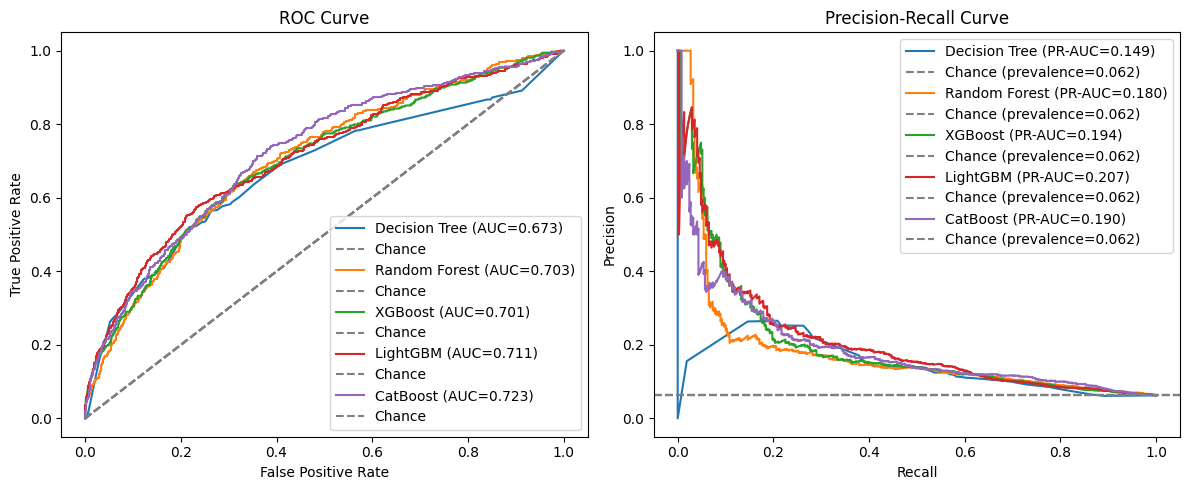

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models_probs = {
    "Logistic Regression": None,  # loaded separately below if needed
    "Decision Tree": dt_val_prob,
    "Random Forest": rf_val_prob,
    "XGBoost": xgb_val_prob,
    "LightGBM": lgb_val_prob,
    "CatBoost": cb_val_prob,
}
for name, prob in models_probs.items():
    if prob is None:
        continue
    ev.plot_roc_curve(y_val, prob, model_name=name, ax=axes[0])
    ev.plot_pr_curve(y_val, prob, model_name=name, ax=axes[1])
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "12_all_models_roc_pr.png", dpi=150)
plt.show()


## 7. Save all models

In [11]:
joblib.dump(dt_model, config.MODELS_DIR / "decision_tree.pkl")
joblib.dump(rf_model, config.MODELS_DIR / "random_forest.pkl")
joblib.dump(xgb_model, config.MODELS_DIR / "xgboost_model.pkl")
joblib.dump(lgb_model, config.MODELS_DIR / "lightgbm_model.pkl")
cb_model.save_model(str(config.MODELS_DIR / "catboost_model.cbm"))
print("All models saved to models/")


All models saved to models/


---
### What to send back to Claude after running this notebook

- Section 6's comparison table (all 5 models + the Phase 13 baseline)
- Any model that clearly underperforms or overfits (large val vs train gap
  — not shown here but worth checking if a number looks suspiciously perfect)

With that, **Phase 14 is complete**, and we move to **Phase 15
(Hyperparameter Tuning)** — tuning the strongest model(s) from this
comparison using RandomizedSearchCV/Optuna, with the test set still
completely untouched.
